In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [15]:
# Sample electricity consumption and bill data

data = {
    'Units_Consumed': [50, 75, 100, 125, 150, 175, 200, 225, 250, 275,
                       300, 325, 350, 375, 400, 425, 450, 475, 500, 525],
    
    'Electricity_Bill': [350, 480, 620, 750, 900, 1030, 1180, 1320, 1470, 1600,
                         1750, 1880, 2030, 2180, 2320, 2470, 2600, 2760, 2900, 3050]
}

df = pd.DataFrame(data)

# Display the dataset
df.head()


,Units_Consumed,Electricity_Bill
0,50,350
1,75,480
2,100,620
3,125,750
4,150,900


In [16]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (20, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Units_Consumed    20 non-null     int64
 1   Electricity_Bill  20 non-null     int64
dtypes: int64(2)
memory usage: 452.0 bytes
None

Missing Values:
Units_Consumed      0
Electricity_Bill    0
dtype: int64


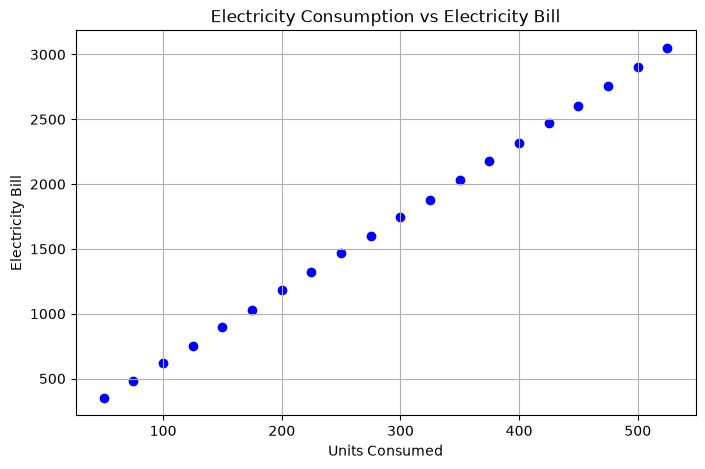

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Units_Consumed'], df['Electricity_Bill'], color='blue')

plt.xlabel('Units Consumed')
plt.ylabel('Electricity Bill')
plt.title('Electricity Consumption vs Electricity Bill')

plt.grid(True)
plt.show()


In [18]:
# X = input feature
# y = target/output

X = df[['Units_Consumed']]
y = df['Electricity_Bill']

print("Input:")
print(X.head())

print("\nOutput:")
print(y.head())


Input:
   Units_Consumed
0              50
1              75
2             100
3             125
4             150

Output:
0    350
1    480
2    620
3    750
4    900
Name: Electricity_Bill, dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (16, 1)
Testing data: (4, 1)


In [20]:
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")


Model training completed!


In [21]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

print("\nLinear Regression Equation:")
print(f"Electricity Bill = {model.intercept_:.2f} + "
      f"({model.coef_[0]:.2f} × Units Consumed)")


Intercept: 36.367063791283954
Coefficient: 5.713889307796711

Linear Regression Equation:
Electricity Bill = 36.37 + (5.71 × Units Consumed)


In [22]:
y_pred = model.predict(X_test)

# Display actual and predicted values
result = pd.DataFrame({
    'Units Consumed': X_test['Units_Consumed'],
    'Actual Bill': y_test,
    'Predicted Bill': y_pred
})

result = result.sort_values('Units Consumed')

print(result)


    Units Consumed  Actual Bill  Predicted Bill
0               50          350      322.061529
1               75          480      464.908762
15             425         2470     2464.770020
17             475         2760     2750.464485


In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Model Evaluation
-----------------
Mean Absolute Error (MAE): 14.45
Mean Squared Error (MSE): 281.65
Root Mean Squared Error (RMSE): 16.78
R² Score: 0.9998


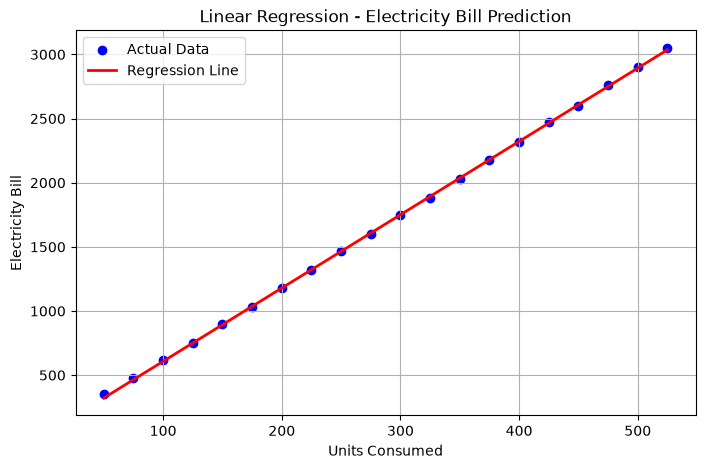

In [24]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(
    X,
    model.predict(X),
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Units Consumed')
plt.ylabel('Electricity Bill')
plt.title('Linear Regression - Electricity Bill Prediction')
plt.legend()
plt.grid(True)

plt.show()


In [26]:
units = float(input("Enter electricity units consumed: "))

prediction = model.predict([[units]])

print(f"\nUnits Consumed: {units}")
print(f"Predicted Electricity Bill: ₹{prediction[0]:.2f}")


Enter electricity units consumed:  400



Units Consumed: 400.0
Predicted Electricity Bill: ₹2321.92


C:\Users\IP LAB 29\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


========== ELECTRICITY BILL PREDICTION ==========
Intercept: 36.37
Coefficient: 5.71

Model Equation:
Bill = 36.37 + (5.71 × Units)

========== MODEL PERFORMANCE ==========
MAE  : 14.45
MSE  : 281.65
RMSE : 16.78
R²   : 0.9998


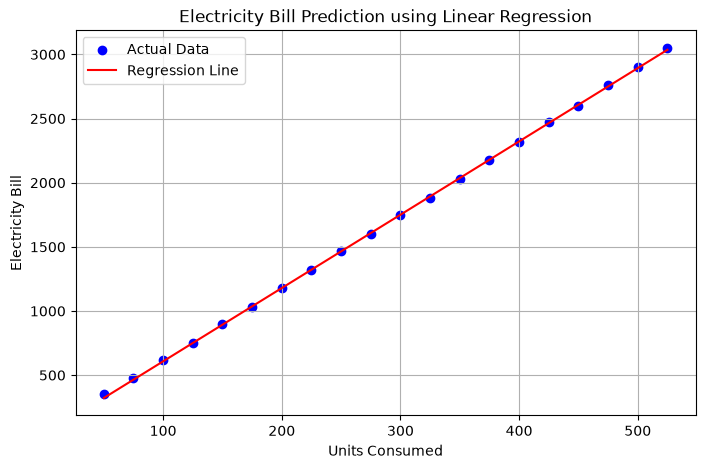


Enter electricity units consumed:  600


Predicted Electricity Bill: ₹3464.70


C:\Users\IP LAB 29\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create dataset
data = {
    'Units_Consumed': [50, 75, 100, 125, 150, 175, 200, 225, 250, 275,
                       300, 325, 350, 375, 400, 425, 450, 475, 500, 525],
    'Electricity_Bill': [350, 480, 620, 750, 900, 1030, 1180, 1320, 1470, 1600,
                         1750, 1880, 2030, 2180, 2320, 2470, 2600, 2760, 2900, 3050]
}

df = pd.DataFrame(data)

# Input and output
X = df[['Units_Consumed']]
y = df['Electricity_Bill']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("========== ELECTRICITY BILL PREDICTION ==========")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")

print("\nModel Equation:")
print(f"Bill = {model.intercept_:.2f} + "
      f"({model.coef_[0]:.2f} × Units)")

print("\n========== MODEL PERFORMANCE ==========")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')

plt.xlabel('Units Consumed')
plt.ylabel('Electricity Bill')
plt.title('Electricity Bill Prediction using Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

# New prediction
units = float(input("\nEnter electricity units consumed: "))
prediction = model.predict([[units]])

print(f"Predicted Electricity Bill: ₹{prediction[0]:.2f}")
